<a href="https://colab.research.google.com/github/madhumitadas28/iris-ann-/blob/main/HandWritten_Digits_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns


In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training Images :", X_train.shape)
print("Testing Images  :", X_test.shape)

Training Images : (60000, 28, 28)
Testing Images  : (10000, 28, 28)


In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [ ]:
model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Step 6 : Train Model

history = model.fit(X_train,
                    y_train,
                    epochs=10,
                    validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9204 - loss: 0.2690 - val_accuracy: 0.9532 - val_loss: 0.1576
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9655 - loss: 0.1141 - val_accuracy: 0.9678 - val_loss: 0.1122
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9766 - loss: 0.0756 - val_accuracy: 0.9731 - val_loss: 0.0889
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9817 - loss: 0.0585 - val_accuracy: 0.9713 - val_loss: 0.0940
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9856 - loss: 0.0439 - val_accuracy: 0.9718 - val_loss: 0.1017
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9881 - loss: 0.0355 - val_accuracy: 0.9751 - val_loss: 0.0964
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9905 - loss: 0.0286 - val_accuracy: 0.9744 - val_loss: 0.1027
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9915 - loss: 0.0243 -

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("\nTest Accuracy = {:.2f}%".format(accuracy*100))


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9784 - loss: 0.0900

Test Accuracy = 97.84%


In [ ]:
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [ ]:
print("\nFirst 10 Predictions\n")

for i in range(10):
    print("Image", i+1,
          " Predicted =", predicted_classes[i],
          " Actual =", y_test[i])



First 10 Predictions

Image 1  Predicted = 7  Actual = 7
Image 2  Predicted = 2  Actual = 2
Image 3  Predicted = 1  Actual = 1
Image 4  Predicted = 0  Actual = 0
Image 5  Predicted = 4  Actual = 4
Image 6  Predicted = 1  Actual = 1
Image 7  Predicted = 4  Actual = 4
Image 8  Predicted = 9  Actual = 9
Image 9  Predicted = 5  Actual = 5
Image 10  Predicted = 9  Actual = 9


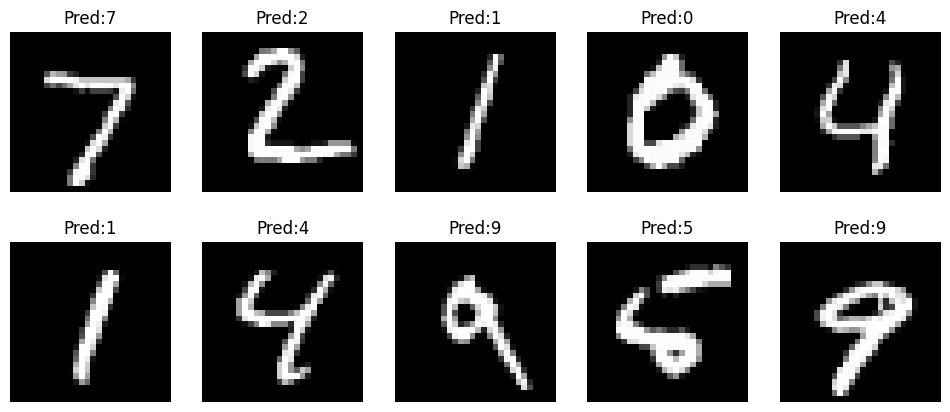

In [ ]:

plt.figure(figsize=(12,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title("Pred:"+str(predicted_classes[i]))
    plt.axis('off')

plt.show()

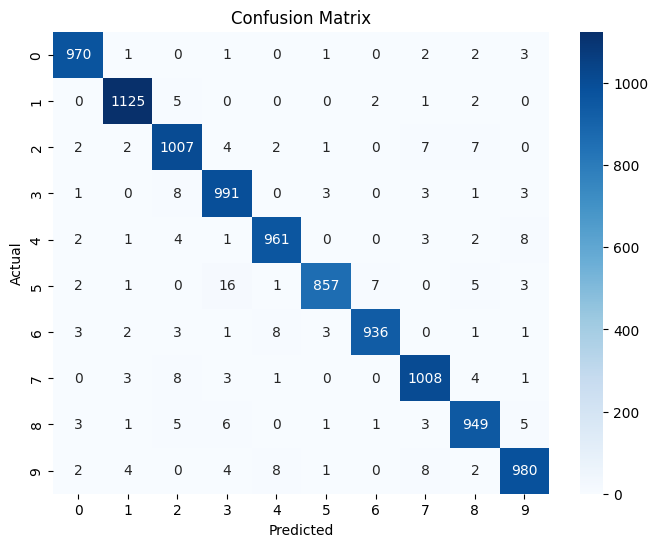

In [ ]:
cm = confusion_matrix(y_test, predicted_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
print("\nClassification Report\n")

print(classification_report(y_test, predicted_classes))


Classification Report

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.98      0.97      1032
           3       0.96      0.98      0.97      1010
           4       0.98      0.98      0.98       982
           5       0.99      0.96      0.97       892
           6       0.99      0.98      0.98       958
           7       0.97      0.98      0.98      1028
           8       0.97      0.97      0.97       974
           9       0.98      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000

